Proxy files: 14
Toby files:   13
Common:       13
Only in proxy (1): ['NGC4698']

Total paired finite spaxels available: 3,029,615
  Finite in proxy only (not paired): 7
  Finite in toby only (not paired):   1,600
Paired positive spaxels within [0.001, 1000.0]: 3,006,101


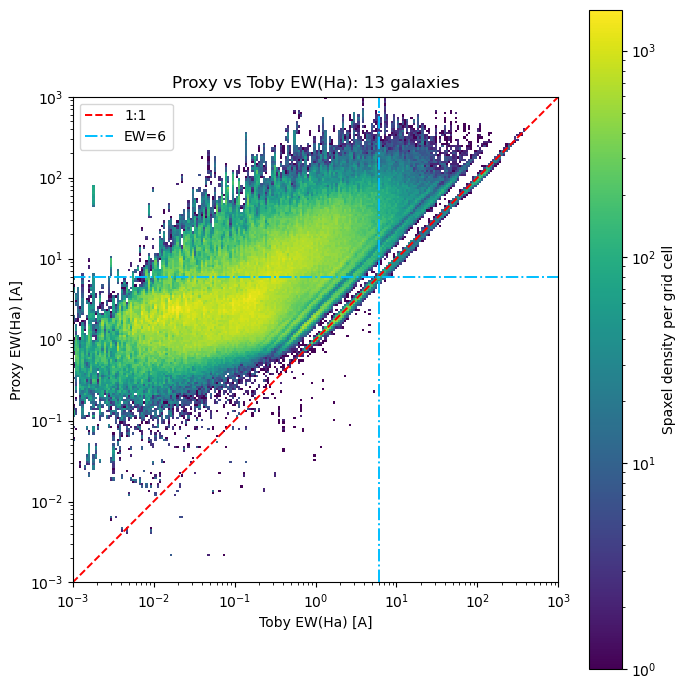

log10(proxy/toby) [plotted points]: median=1.5015, 16-84%=[0.9060, 2.2065]


In [1]:
# ------------------------------------------------------------------
# Compare EW(Ha): proxy_EW_maps vs toby gas maps
# Use only galaxies that exist in both file sets.
# Plot ALL paired finite spaxels in a gridded (density-colored) space.
# Requested view: x=Toby, y=Proxy; axis limits [0.001, 1000].
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits

PROXY_PATTERN = "*_proxy_EW_maps.fits"
TOBY_PATTERN = "*_v0.7dev_gas_BIN_maps.fits"
PROXY_HDU = "PROXY_EWHA"
TOBY_HDU = "HA6562_EW"

PLOT_MIN = 0.001
PLOT_MAX = 1000.0
EW_LINE = 6.0
NBINS = 220  # grid resolution in log space (higher -> finer grid)

# Build galaxy -> file maps for both EW sources
proxy_files = {
    p.name.replace("_proxy_EW_maps.fits", ""): p
    for p in sorted(Path(".").glob(PROXY_PATTERN))
}
toby_files = {
    p.name.replace("_v0.7dev_gas_BIN_maps.fits", ""): p
    for p in sorted(Path(".").glob(TOBY_PATTERN))
}

if len(proxy_files) == 0:
    raise FileNotFoundError(f"No files found matching {PROXY_PATTERN}")
if len(toby_files) == 0:
    raise FileNotFoundError(f"No files found matching {TOBY_PATTERN}")

common_galaxies = sorted(set(proxy_files) & set(toby_files))
only_proxy = sorted(set(proxy_files) - set(toby_files))
only_toby = sorted(set(toby_files) - set(proxy_files))

if len(common_galaxies) == 0:
    raise RuntimeError("No overlapping galaxies found between proxy and toby EW files.")

print(f"Proxy files: {len(proxy_files)}")
print(f"Toby files:   {len(toby_files)}")
print(f"Common:       {len(common_galaxies)}")
if only_proxy:
    print(f"Only in proxy ({len(only_proxy)}): {only_proxy}")
if only_toby:
    print(f"Only in toby ({len(only_toby)}): {only_toby}")

proxy_all = []
toby_all = []
skipped_shape = []
missing_hdu = []

n_paired_finite = 0
n_proxy_only = 0
n_toby_only = 0

for galaxy in common_galaxies:
    proxy_path = proxy_files[galaxy]
    toby_path = toby_files[galaxy]

    with fits.open(proxy_path) as hp:
        if PROXY_HDU not in hp:
            missing_hdu.append((galaxy, proxy_path.name, PROXY_HDU))
            continue
        proxy_map = np.array(hp[PROXY_HDU].data, dtype=float)

    with fits.open(toby_path) as ht:
        if TOBY_HDU not in ht:
            missing_hdu.append((galaxy, toby_path.name, TOBY_HDU))
            continue
        toby_map = np.array(ht[TOBY_HDU].data, dtype=float)

    if proxy_map.shape != toby_map.shape:
        skipped_shape.append((galaxy, proxy_map.shape, toby_map.shape))
        continue

    finite_proxy = np.isfinite(proxy_map)
    finite_toby = np.isfinite(toby_map)
    paired_finite = finite_proxy & finite_toby

    if np.any(paired_finite):
        proxy_all.append(proxy_map[paired_finite].ravel())
        toby_all.append(toby_map[paired_finite].ravel())
        n_paired_finite += np.count_nonzero(paired_finite)

    n_proxy_only += np.count_nonzero(finite_proxy & ~finite_toby)
    n_toby_only += np.count_nonzero(~finite_proxy & finite_toby)

if missing_hdu:
    print("\nMissing HDU entries:")
    for item in missing_hdu:
        print(f"  {item[0]}: file={item[1]}, missing_hdu={item[2]}")

if skipped_shape:
    print("\nSkipped due to shape mismatch:")
    for item in skipped_shape:
        print(f"  {item[0]}: proxy{item[1]} vs toby{item[2]}")

if len(proxy_all) == 0:
    raise RuntimeError("No paired finite spaxels found.")

proxy_vals = np.concatenate(proxy_all)
toby_vals = np.concatenate(toby_all)

print(f"\nTotal paired finite spaxels available: {proxy_vals.size:,}")
print(f"  Finite in proxy only (not paired): {n_proxy_only:,}")
print(f"  Finite in toby only (not paired):   {n_toby_only:,}")

# Flip axes as requested: x=Toby, y=Proxy
x = toby_vals
y = proxy_vals

# Apply requested limits and positivity (log-space plotting)
mask = (x > 0) & (y > 0) & (x >= PLOT_MIN) & (x <= PLOT_MAX) & (y >= PLOT_MIN) & (y <= PLOT_MAX)
x_sel = x[mask]
y_sel = y[mask]
print(f"Paired positive spaxels within [{PLOT_MIN}, {PLOT_MAX}]: {x_sel.size:,}")

# Grid-segment the plotting space in log10 coordinates, then color by density
logx = np.log10(x_sel)
logy = np.log10(y_sel)
edges = np.linspace(np.log10(PLOT_MIN), np.log10(PLOT_MAX), NBINS + 1)
H, xedges, yedges = np.histogram2d(logx, logy, bins=[edges, edges])

fig, ax = plt.subplots(figsize=(7, 7))
# pcolormesh expects edges in data coordinates -> convert back from log10
pcm = ax.pcolormesh(
    10 ** xedges,
    10 ** yedges,
    H.T,
    norm=LogNorm(vmin=1, vmax=max(1, H.max())),
    shading="auto",
    cmap="viridis",
)

ax.plot([PLOT_MIN, PLOT_MAX], [PLOT_MIN, PLOT_MAX], "r--", lw=1.4, label="1:1")
ax.axvline(EW_LINE, color="deepskyblue", ls="-.", lw=1.4, label=f"EW={EW_LINE:g}")
ax.axhline(EW_LINE, color="deepskyblue", ls="-.", lw=1.4, label="_nolegend_")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(PLOT_MIN, PLOT_MAX)
ax.set_ylim(PLOT_MIN, PLOT_MAX)
ax.set_xlabel("Toby EW(Ha) [A]")
ax.set_ylabel("Proxy EW(Ha) [A]")
ax.set_title(f"Proxy vs Toby EW(Ha): {len(common_galaxies)} galaxies")
ax.legend(loc="upper left")
ax.set_aspect("equal", adjustable="box")

cb = fig.colorbar(pcm, ax=ax)
cb.set_label("Spaxel density per grid cell")

plt.tight_layout()
plt.show()

# Agreement diagnostics in log-space over the plotted points
if x_sel.size > 0:
    log_ratio = np.log10(y_sel / x_sel)  # proxy/toby, but axes are flipped
    p16, p50, p84 = np.percentile(log_ratio, [16, 50, 84])
    print(f"log10(proxy/toby) [plotted points]: median={p50:.4f}, 16-84%=[{p16:.4f}, {p84:.4f}]")
else:
    print("No points in the requested plotting window for log10(proxy/toby) diagnostics.")


  Used galaxies: 14
  Valid spaxels (flux+SFR+EW>0): 2,705,301

  Used galaxies: 13
  Valid spaxels (flux+SFR+EW>0): 2,486,411
  Missing files: 1


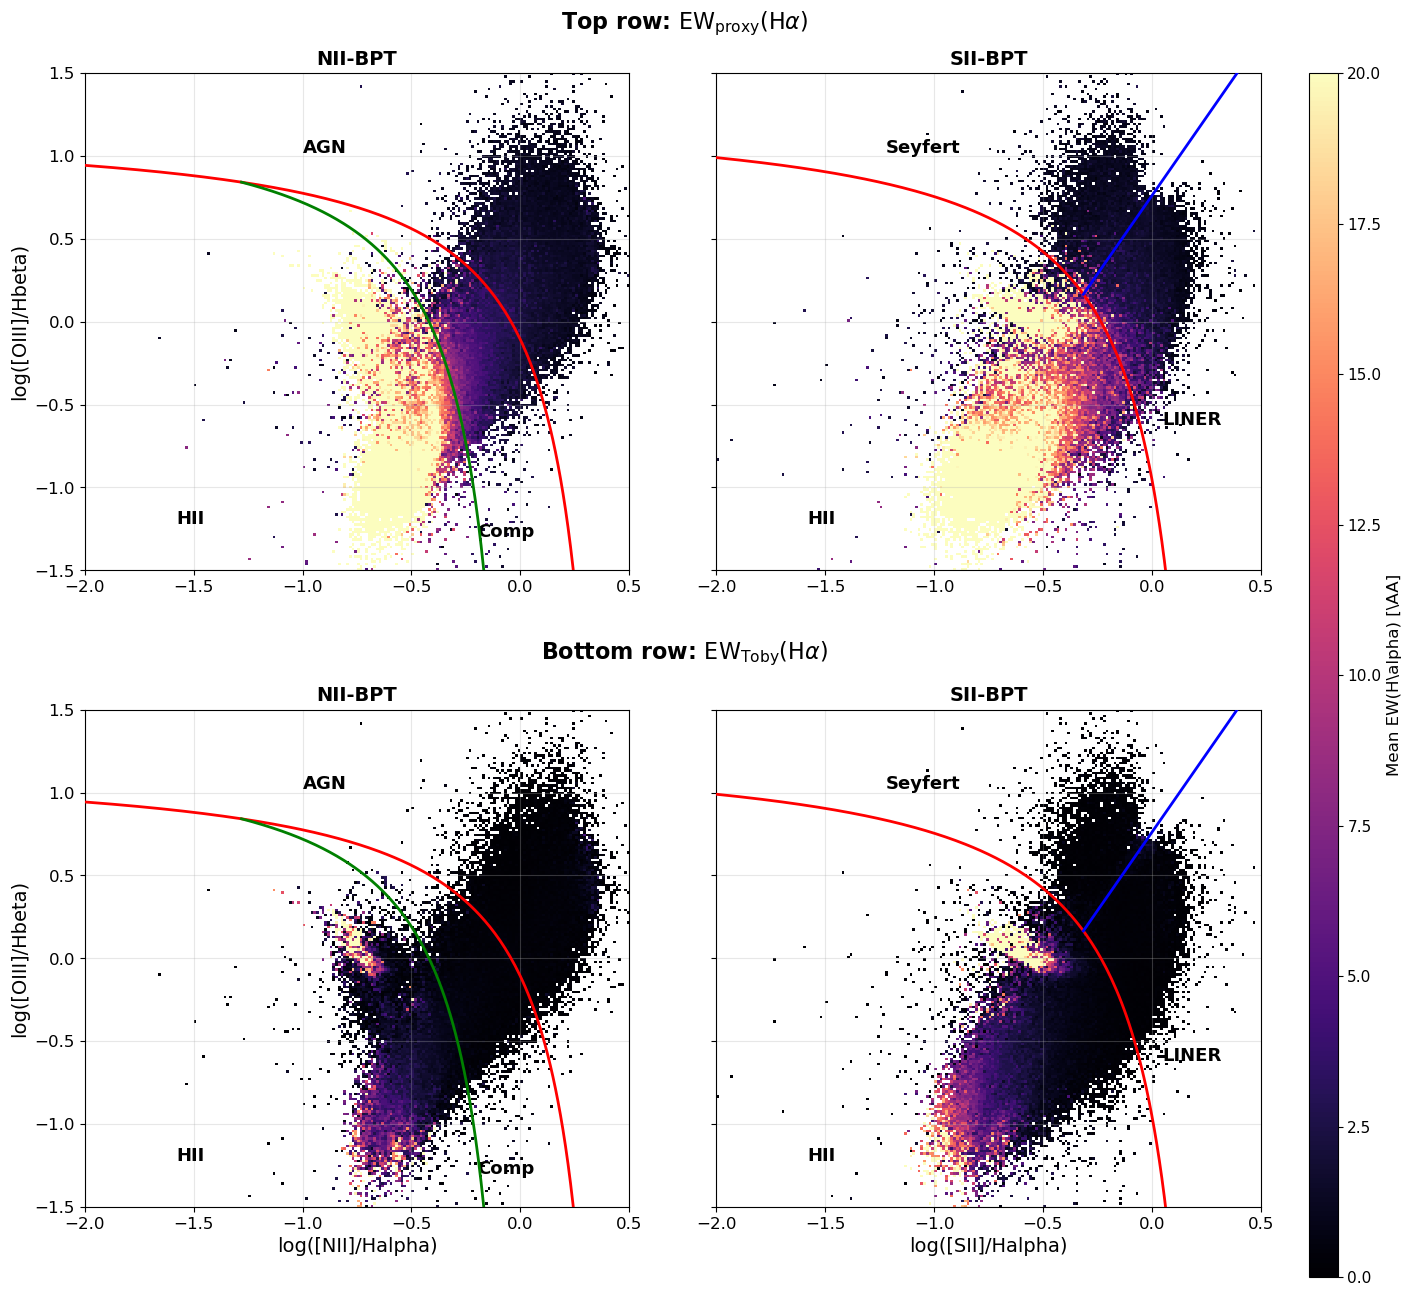


Successfully created 2x2 BPT panels (proxy EW and Toby EW).
Galaxies from binning maps: 14
Color quantity: mean EW(Halpha) in each BPT bin (linear scale, colorbar 0-20); bins with <3 spaxels are masked


In [2]:
# ------------------------------------------------------------------
# Combined 2x2 BPT figure:
#   Top row    -> EW_proxy(Halpha): NII and SII
#   Bottom row -> EW_Toby(Halpha):   NII and SII
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits


# BPT reference line functions (for drawing curves only)
def kewley01_N2(x):
    return 0.61 / (x - 0.47) + 1.19


def kauff03_N2(x):
    return 0.61 / (x - 0.05) + 1.30


def kewley01_S2(x):
    return 0.72 / (x - 0.32) + 1.30


def kewley06_Sy_LIN(x):
    return 1.89 * x + 0.76


def build_mean_ew_grid(xvals, yvals, ew_vals, bins_2d, xlim, ylim, min_count_per_bin):
    grid_count, xedges, yedges = np.histogram2d(
        xvals,
        yvals,
        bins=bins_2d,
        range=[xlim, ylim],
    )
    grid_sum_ew, _, _ = np.histogram2d(
        xvals,
        yvals,
        bins=bins_2d,
        range=[xlim, ylim],
        weights=ew_vals,
    )
    grid_mean_ew = np.divide(
        grid_sum_ew,
        grid_count,
        out=np.full_like(grid_sum_ew, np.nan, dtype=float),
        where=grid_count > 0,
    )
    grid_mean_ew[grid_count < min_count_per_bin] = np.nan
    return grid_mean_ew, xedges, yedges


def collect_spaxels_for_ew_source(galaxies, ew_suffix, ew_hdu, source_name):
    all_logN2 = []
    all_logO3 = []
    all_logS2 = []
    all_ew = []

    missing_files = []
    missing_hdu = []
    shape_mismatch = []
    used_galaxies = []

    required_gas_hdus = [
        "HB4861_FLUX_CORR",
        "HA6562_FLUX_CORR",
        "OIII5006_FLUX_CORR",
        "NII6583_FLUX_CORR",
        "SII6716_FLUX_CORR",
        "SII6730_FLUX_CORR",
        "LOGSFR_SURFACE_DENSITY_HII",
        "LOGSFR_SURFACE_DENSITY_NONHII",
        "LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2",
    ]

    n_valid_total = 0

    for gal in galaxies:
        gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
        ew_file = Path(f"{gal}{ew_suffix}")

        if not gas_file.exists() or not ew_file.exists():
            missing_files.append(gal)
            continue

        with fits.open(gas_file) as h:
            missing_gas_hdus = [name for name in required_gas_hdus if name not in h]
            if missing_gas_hdus:
                missing_hdu.append((gal, gas_file.name, ", ".join(missing_gas_hdus)))
                continue

            HB4861_FLUX_corr = h["HB4861_FLUX_CORR"].data
            HA6562_FLUX_corr = h["HA6562_FLUX_CORR"].data
            OIII5006_FLUX_corr = h["OIII5006_FLUX_CORR"].data
            NII6583_FLUX_corr = h["NII6583_FLUX_CORR"].data
            SII6716_FLUX_corr = h["SII6716_FLUX_CORR"].data
            SII6730_FLUX_corr = h["SII6730_FLUX_CORR"].data

            logSigmaSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
            logSigmaSFR_NONHII = h["LOGSFR_SURFACE_DENSITY_NONHII"].data
            logSigmaSFR_UNCLASS = h["LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2"].data

        with fits.open(ew_file) as h_ew:
            if ew_hdu not in h_ew:
                missing_hdu.append((gal, ew_file.name, ew_hdu))
                continue
            ew_ha = h_ew[ew_hdu].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            shape_mismatch.append((gal, ew_ha.shape, HA6562_FLUX_corr.shape))
            continue

        flux_mask = (
            np.isfinite(HB4861_FLUX_corr)
            & (HB4861_FLUX_corr > 0)
            & np.isfinite(HA6562_FLUX_corr)
            & (HA6562_FLUX_corr > 0)
            & np.isfinite(OIII5006_FLUX_corr)
            & (OIII5006_FLUX_corr > 0)
            & np.isfinite(NII6583_FLUX_corr)
            & (NII6583_FLUX_corr > 0)
            & np.isfinite(SII6716_FLUX_corr)
            & (SII6716_FLUX_corr > 0)
            & np.isfinite(SII6730_FLUX_corr)
            & (SII6730_FLUX_corr > 0)
        )

        sfr_mask = (
            np.isfinite(logSigmaSFR_HII)
            | np.isfinite(logSigmaSFR_NONHII)
            | np.isfinite(logSigmaSFR_UNCLASS)
        )

        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)
        valid_mask = flux_mask & sfr_mask & ew_mask

        n_valid = int(np.count_nonzero(valid_mask))
        if n_valid == 0:
            continue

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.append(logN2.ravel())
        all_logO3.append(logO3.ravel())
        all_logS2.append(logS2.ravel())
        all_ew.append(EW_common.ravel())

        used_galaxies.append(gal)
        n_valid_total += n_valid

    if len(all_logN2) == 0:
        raise RuntimeError(f"No valid spaxels remained for {source_name}.")

    result = {
        "logN2": np.concatenate(all_logN2),
        "logO3": np.concatenate(all_logO3),
        "logS2": np.concatenate(all_logS2),
        "ew": np.concatenate(all_ew),
        "used_galaxies": sorted(set(used_galaxies)),
        "n_valid_total": n_valid_total,
        "missing_files": missing_files,
        "missing_hdu": missing_hdu,
        "shape_mismatch": shape_mismatch,
    }
    return result


# Create x arrays for reference lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286 - np.sqrt(2871561)) / 1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159 - np.sqrt(105081)) / 525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = sorted({f.name.split("_")[0] for f in bins})
if len(galaxies) == 0:
    raise RuntimeError("No *_SPATIAL_BINNING_maps_extended.fits files found.")


EW_SOURCES = [
    {
        "key": "proxy",
        "title": r"$\mathrm{EW}_{\rm proxy}(\mathrm{H}\alpha)$",
        "ew_suffix": "_proxy_EW_maps.fits",
        "ew_hdu": "PROXY_EWHA",
    },
    {
        "key": "toby",
        "title": r"$\mathrm{EW}_{\rm Toby}(\mathrm{H}\alpha)$",
        "ew_suffix": "_v0.7dev_gas_BIN_maps.fits",
        "ew_hdu": "HA6562_EW",
    },
]


results = {}
for src in EW_SOURCES:
    print(f"\nCollecting all spaxels for {src['title']} ...")
    res = collect_spaxels_for_ew_source(
        galaxies=galaxies,
        ew_suffix=src["ew_suffix"],
        ew_hdu=src["ew_hdu"],
        source_name=src["title"],
    )
    results[src["key"]] = res

    print(f"  Used galaxies: {len(res['used_galaxies'])}")
    print(f"  Valid spaxels (flux+SFR+EW>0): {res['n_valid_total']:,}")
    if len(res["missing_files"]) > 0:
        print(f"  Missing files: {len(res['missing_files'])}")
    if len(res["missing_hdu"]) > 0:
        print(f"  Missing HDU entries: {len(res['missing_hdu'])}")
    if len(res["shape_mismatch"]) > 0:
        print(f"  Shape mismatches: {len(res['shape_mismatch'])}")


# ------------------------------------------------------------------
# Build 2x2 BPT plot (rows = EW source, columns = NII/SII)
# ------------------------------------------------------------------
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3

vmin_ew = 0.0
vmax_ew = 20.0

fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharey=True)
plt.subplots_adjust(wspace=0.16, hspace=0.28, top=0.92, right=0.86)

last_img = None

for row_idx, src in enumerate(EW_SOURCES):
    data = results[src["key"]]

    grid_mean_N2, xedges_N2, yedges_N2 = build_mean_ew_grid(
        data["logN2"],
        data["logO3"],
        data["ew"],
        bins_2d=bins_2d,
        xlim=xlim,
        ylim=ylim,
        min_count_per_bin=min_count_per_bin,
    )

    grid_mean_S2, xedges_S2, yedges_S2 = build_mean_ew_grid(
        data["logS2"],
        data["logO3"],
        data["ew"],
        bins_2d=bins_2d,
        xlim=xlim,
        ylim=ylim,
        min_count_per_bin=min_count_per_bin,
    )

    # Left panel: NII-BPT
    ax_n2 = axes[row_idx, 0]
    img_n2 = ax_n2.pcolormesh(
        xedges_N2,
        yedges_N2,
        np.ma.masked_invalid(grid_mean_N2.T),
        cmap="magma",
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading="auto",
    )
    ax_n2.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), "r-", lw=2, label="Kewley+01", zorder=10)
    ax_n2.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), "g-", lw=2, label="Kauffmann+03", zorder=10)
    ax_n2.set_xlim(xlim)
    ax_n2.set_ylim(ylim)
    ax_n2.set_ylabel("log([OIII]/Hbeta)", fontsize=14)
    ax_n2.tick_params(axis="both", which="major", labelsize=12)
    ax_n2.grid(True, alpha=0.3)
    ax_n2.text(-1.58, -1.22, "HII", fontsize=13, fontweight="bold")
    ax_n2.text(-0.20, -1.30, "Comp", fontsize=13, fontweight="bold")
    ax_n2.text(-1.00, 1.02, "AGN", fontsize=13, fontweight="bold")

    # Right panel: SII-BPT
    ax_s2 = axes[row_idx, 1]
    img_s2 = ax_s2.pcolormesh(
        xedges_S2,
        yedges_S2,
        np.ma.masked_invalid(grid_mean_S2.T),
        cmap="magma",
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading="auto",
    )
    ax_s2.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), "r-", lw=2, label="Kewley+01", zorder=10)
    ax_s2.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), "b-", lw=2, label="Kewley+06", zorder=10)
    ax_s2.set_xlim(xlim)
    ax_s2.set_ylim(ylim)
    ax_s2.tick_params(axis="both", which="major", labelsize=12)
    ax_s2.tick_params(axis="y", labelleft=False)
    ax_s2.grid(True, alpha=0.3)
    ax_s2.text(-1.58, -1.22, "HII", fontsize=13, fontweight="bold")
    ax_s2.text(-1.22, 1.02, "Seyfert", fontsize=13, fontweight="bold")
    ax_s2.text(0.05, -0.62, "LINER", fontsize=13, fontweight="bold")

    axes[row_idx, 0].set_title("NII-BPT", fontsize=14, fontweight="bold")
    axes[row_idx, 1].set_title("SII-BPT", fontsize=14, fontweight="bold")

    if row_idx == len(EW_SOURCES) - 1:
        ax_n2.set_xlabel("log([NII]/Halpha)", fontsize=14)
        ax_s2.set_xlabel("log([SII]/Halpha)", fontsize=14)

    last_img = img_s2


# Row-level titles for the two EW definitions
fig.text(
    0.5,
    0.955,
    f"Top row: {EW_SOURCES[0]['title']}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.5,
    0.505,
    f"Bottom row: {EW_SOURCES[1]['title']}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
)


# Shared colorbar for all 4 panels (tall to span nearly full figure height)
cax = fig.add_axes([0.89, 0.06, 0.018, 0.86])
cbar = fig.colorbar(last_img, cax=cax)
cbar.set_label(r"Mean EW(H\alpha) [\AA]", fontsize=12)
cbar.ax.tick_params(labelsize=11)

# Save figures (optional)
# fig.savefig('Plot_Paper_1/Combined_BPT_2x2_by_EW_source.png', dpi=600, bbox_inches='tight')
# fig.savefig('Plot_Paper_1/Combined_BPT_2x2_by_EW_source.pdf', bbox_inches='tight')

plt.show()

print("\nSuccessfully created 2x2 BPT panels (proxy EW and Toby EW).")
print(f"Galaxies from binning maps: {len(galaxies)}")
print(
    f"Color quantity: mean EW(Halpha) in each BPT bin (linear scale, colorbar 0-20); "
    f"bins with <{min_count_per_bin} spaxels are masked"
)
